## Работа с целевой переменной

### Классная работа

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler

#### Отбор признаков ао важности

In [2]:
df = fetch_openml("mtp", version=1)
df.data.head()

,oz1,oz2,oz3,oz4,oz5,oz6,oz7,oz8,oz9,oz10,...,oz193,oz194,oz195,oz196,oz197,oz198,oz199,oz200,oz201,oz202
0,0.076923,0.325000,0.035088,0.200000,0.162112,0.194562,0.003900,0.060606,0.166667,0.045872,...,0.013874,0.071602,0.056880,0.179132,0.505899,0.039213,0.091327,0.321109,0.127564,0.188387
1,0.230769,0.375000,0.042105,0.333333,0.464191,0.622795,0.077623,0.373737,0.305556,0.192661,...,0.006342,0.186056,0.287438,0.384236,0.683820,0.326584,0.117990,0.456665,0.475618,0.401935
2,0.269231,0.437500,0.052632,0.333333,0.506556,0.531840,0.054374,0.212121,0.333333,0.229358,...,0.005018,0.179544,0.117431,0.384550,0.499219,0.204885,0.155967,0.360441,0.497968,0.407742
3,0.153846,0.357143,0.039474,0.266667,0.352880,0.394131,0.019654,0.171717,0.277778,0.091743,...,0.004801,0.091771,0.145349,0.243064,0.630533,0.023469,0.124430,0.336023,0.134458,0.252258
4,0.153846,0.357143,0.039474,0.266667,0.350523,0.320546,0.013154,0.101010,0.166667,0.110092,...,0.011166,0.130755,0.067583,0.250832,0.516053,0.111398,0.125693,0.332113,0.295913,0.253548


[]

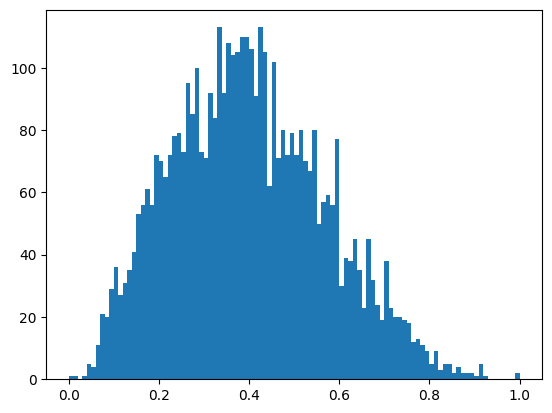

In [3]:
plt.hist(df.target, 100)
plt.plot()

#### Построение базовой модели

In [4]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

In [5]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

-1.6511340763548095

In [6]:
y_pred = baseline.predict(X_train)

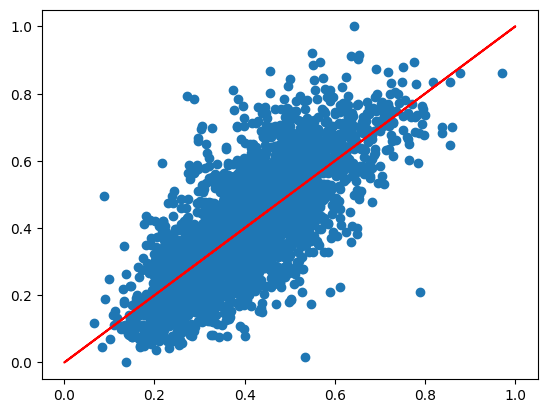

In [7]:
plt.scatter(y_pred, y_train)
plt.plot(y_train, y_train, color='r')

#### Определение относительной важности признаков

In [8]:
rf = RandomForestRegressor(n_estimators=15).fit(X_train, y_train)

Text(0.5, 0, 'Feature Importance')

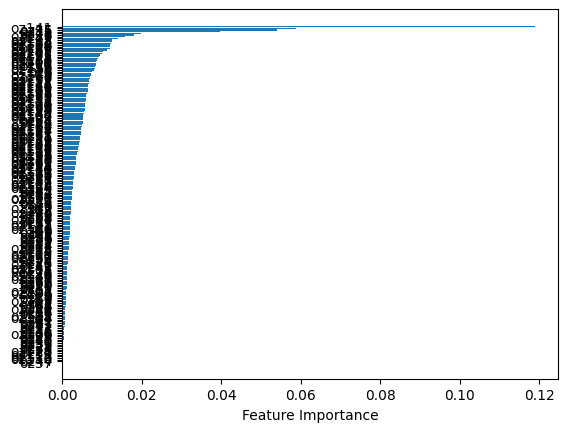

In [9]:
sort = rf.feature_importances_.argsort()
plt.barh(df.data.columns[sort], rf.feature_importances_[sort])
plt.xlabel("Feature Importance")

In [10]:
rf.feature_importances_[sort][-10:]

array([0.01240612, 0.01243824, 0.01406608, 0.01589121, 0.01813691,
       0.01988004, 0.03964024, 0.0539686 , 0.05886547, 0.11884616])

In [11]:
df.data.columns[sort][-10:]

Index(['oz162', 'oz198', 'oz112', 'oz47', 'oz137', 'oz18', 'oz48', 'oz15',
       'oz35', 'oz141'],
      dtype='object')

In [12]:
trimmed = df.data[df.data.columns[sort][-20:]]
trimmed.head()

,oz56,oz178,oz195,oz155,oz201,oz197,oz153,oz20,oz109,oz158,oz162,oz198,oz112,oz47,oz137,oz18,oz48,oz15,oz35,oz141
0,0.126277,0.007949,0.056880,0.752291,0.127564,0.505899,0.052296,0.000000,0.076923,0.800120,0.319206,0.039213,0.000000,0.102941,0.000000,0.0625,0.312855,0.000000,0.0,0.041308
1,0.422015,0.008435,0.287438,0.745984,0.475618,0.683820,0.060922,0.242424,0.153846,0.791224,0.306084,0.326584,0.222222,0.389706,0.278945,0.0625,0.297041,0.282828,0.4,0.212274
2,0.000000,0.008192,0.117431,0.753298,0.497968,0.499219,0.072628,0.388889,0.076923,0.798276,0.406309,0.204885,0.000000,0.257353,0.000000,0.1250,0.288557,0.388889,0.0,0.063643
3,0.000000,0.008107,0.145349,0.767469,0.134458,0.630533,0.054593,0.095238,0.076923,0.800965,0.327848,0.023469,0.000000,0.198529,0.039437,0.0000,0.310692,0.111111,0.1,0.031193
4,0.000000,0.008274,0.067583,0.741548,0.295913,0.516053,0.045400,0.260870,0.076923,0.802893,0.329857,0.111398,0.000000,0.154412,0.000000,0.0625,0.286581,0.304348,0.0,0.063643


In [13]:
X_train, X_test, y_train, y_test = train_test_split(trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)
y_pred = better.predict(X_test)
print(bl_score)
better.score(X_test, y_test)

-1.6511340763548095


0.4019192539919727

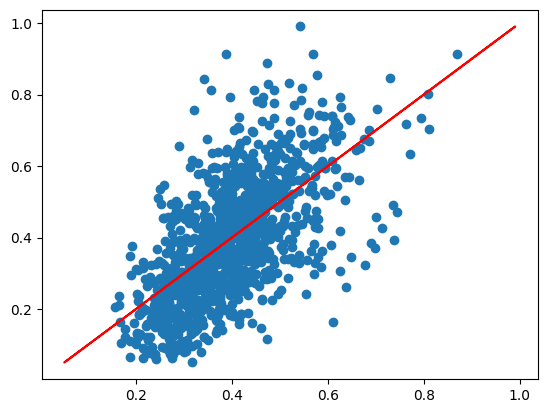

In [14]:
plt.scatter(y_pred, y_test)
plt.plot(y_test, y_test, color='r')

#### Автоматизация отбора признаков

In [15]:
df.data.shape

(4450, 202)

In [16]:
sfm = SelectFromModel(RandomForestRegressor(n_estimators=15)).fit(df.data, df.target)
X_trimmed = sfm.transform(df.data)
X_trimmed.shape

(4450, 54)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)

print(bl_score)
better.score(X_test, y_test)

-1.6511340763548095


0.4377553434891708

#### Устранение дисбаланса классов

In [18]:
df = fetch_openml("balance-scale", version=1)
df.data.head()

,left-weight,left-distance,right-weight,right-distance
0,1,1,1,1
1,1,1,1,2
2,1,1,1,3
3,1,1,1,4
4,1,1,1,5


(array([ 49.,   0.,   0.,   0.,   0., 288.,   0.,   0.,   0., 288.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

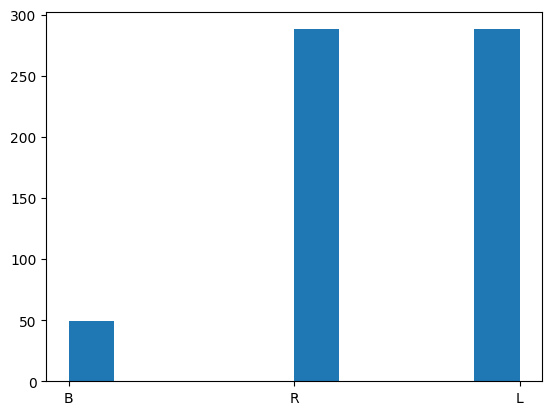

In [19]:
plt.hist(df.target)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42, stratify=df.target)

(array([216.,   0.,   0.,   0.,   0., 215.,   0.,   0.,   0.,  37.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

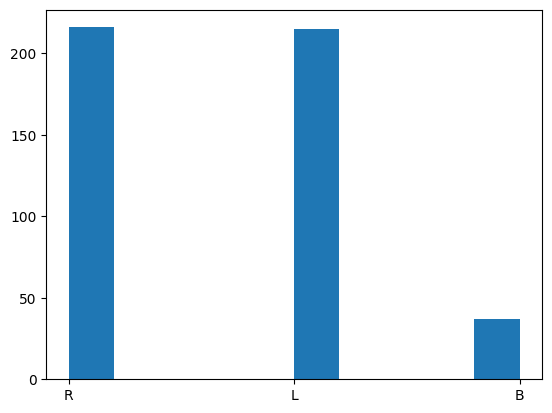

In [21]:
plt.hist(y_train)

In [22]:
baseline = LogisticRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

0.8598726114649682

In [23]:
print(classification_report(y_test, baseline.predict(X_test)))

              precision    recall  f1-score   support

           B       0.00      0.00      0.00        12
           L       0.87      0.92      0.89        73
           R       0.86      0.94      0.90        72

    accuracy                           0.86       157
   macro avg       0.58      0.62      0.60       157
weighted avg       0.80      0.86      0.83       157



In [24]:
print(confusion_matrix(y_test, baseline.predict(X_test)))

[[ 0  6  6]
 [ 1 67  5]
 [ 0  4 68]]


In [25]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))
class_weights

{'B': np.float64(4.216216216216216),
 'L': np.float64(0.7255813953488373),
 'R': np.float64(0.7222222222222222)}

In [26]:
weighted = LogisticRegression(class_weight=class_weights)
weighted.fit(X_train, y_train)
print(bl_score)
weighted.score(X_test, y_test)

0.8598726114649682


0.9235668789808917

In [27]:
print(classification_report(y_test, weighted.predict(X_test)))

              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157



#### Oversampling

In [28]:
y_train.value_counts()

,count
class,
R,216
L,215
B,37


In [29]:
X_train["target"] = y_train

In [30]:
oversampled = X_train[X_train.target == "B"].sample(n=216-37, replace=True, ignore_index=True)

In [31]:
oversampled = pd.concat([X_train, oversampled])
print(oversampled.shape)
oversampled.head()

(647, 5)


,left-weight,left-distance,right-weight,right-distance,target
262,3,1,3,3,R
401,4,2,1,2,L
174,2,2,5,5,R
81,1,4,2,2,B
36,1,2,3,2,R


(array([216.,   0.,   0.,   0.,   0., 215.,   0.,   0.,   0., 216.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

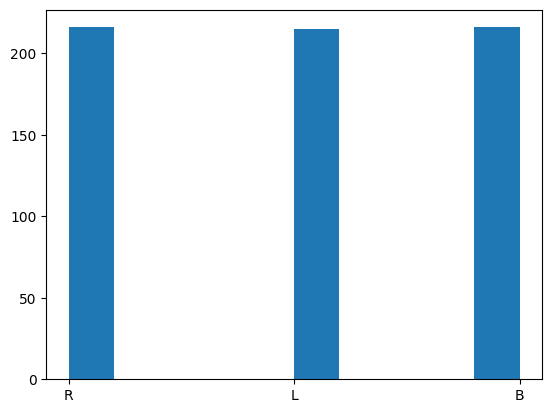

In [32]:
plt.hist(oversampled.target)

In [33]:
y_train_OS = oversampled.target
X_train_OS = oversampled.drop(["target"], axis=1)

In [34]:
OSmodel = LogisticRegression()
OSmodel.fit(X_train_OS, y_train_OS)
print(bl_score)
OSmodel.score(X_test, y_test)

0.8598726114649682


0.9235668789808917

In [35]:
print(classification_report(y_test, OSmodel.predict(X_test)))

              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157



#### Дискретизация целевой переменной

In [36]:
df = fetch_openml("CPMP-2015-regression", version=1)
df.data.drop(["instance_id"], inplace=True, axis=1)
df.data = pd.get_dummies(df.data)
df.data.head()

/tmp/ipykernel_1015/1011001378.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.data.drop(["instance_id"], inplace=True, axis=1)


,repetition,stacks,tiers,stack.tier.ratio,container.density,empty.stack.pct,overstowing.stack.pct,overstowing.2cont.stack.pct,group.same.min,group.same.max,...,avg.l1.top.left.lg.group,cont.empty.grt.estack,pct.bottom.pct.on.top,algorithm_astar.symmulgt.transmul,algorithm_astar.symmullt.transmul,algorithm_idastar.symmulgt.transmul,algorithm_idastar.symmullt.transmul,runstatus_memout,runstatus_ok,runstatus_timeout
0,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,True,False,False,False,False,True,False
1,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,True,False,False,False,True,False
2,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,True,False,False,True,False
3,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,False,True,False,False,True
4,1,16,5,0.3125,0.6,0.1875,0.5625,1.000000,0,7,...,0.663462,0.3375,0.0,True,False,False,False,True,False,False


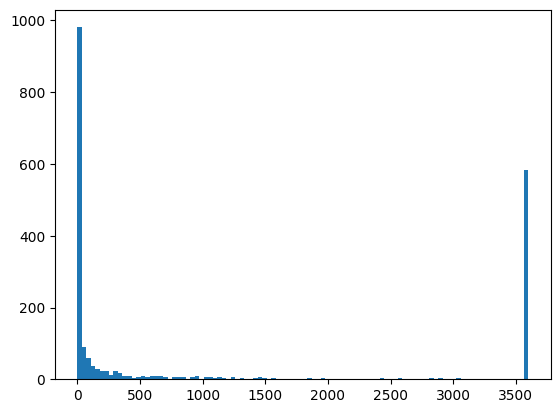

In [37]:
plt.hist(df.target, 100)
_ = plt.plot()

In [38]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

In [39]:
y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="uniform").fit_transform(pd.DataFrame(y_train))

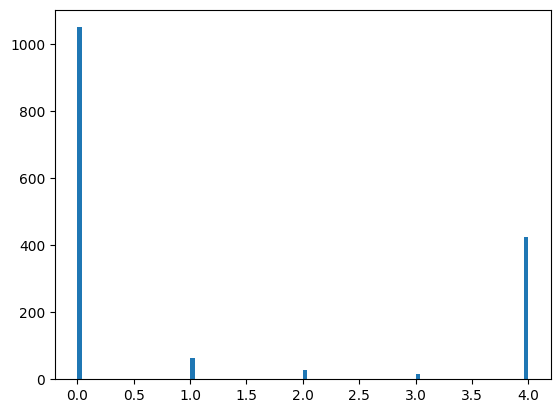

In [40]:
plt.hist(y_binned, 100)
_ = plt.plot()

In [41]:
y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile").fit_transform(pd.DataFrame(y_train))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


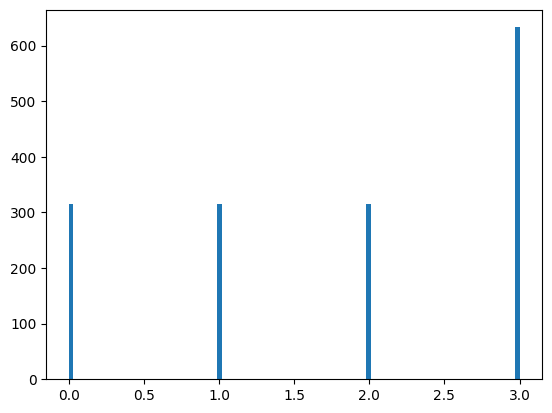

In [42]:
plt.hist(y_binned, 100)
_ = plt.plot()

### Задания для самостоятельного выполнения

#### 1. Исследуйте связь между количеством самых важных признаков, которые использует модель для обучения и тестовой точностью получившейся модели. Обучите несколько моделей с разным количеством наиболее важных признаков. Постройте график зависимости точности модели от количества признаков. Сделайте вывод.

Text(0.5, 0, 'Feature Importance')

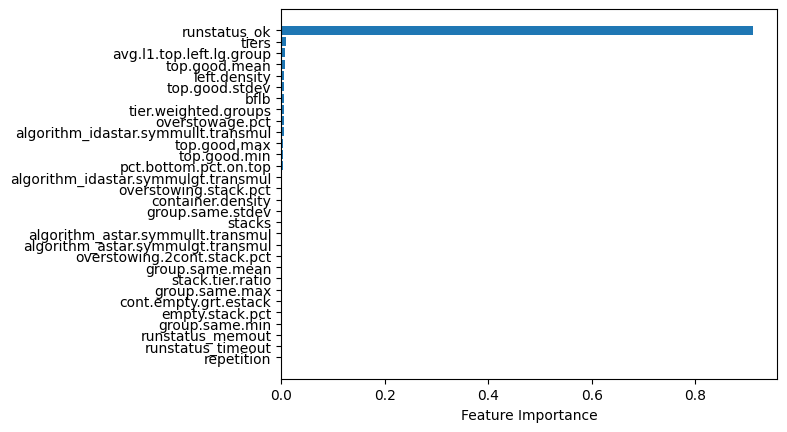

In [43]:
rf = RandomForestRegressor(n_estimators=15).fit(X_train, y_train)
sort = rf.feature_importances_.argsort()
plt.barh(df.data.columns[sort], rf.feature_importances_[sort])
plt.xlabel("Feature Importance")


In [44]:
scores = {}
for i in range(5, 50):
  rf.feature_importances_[sort][-i:]
  trimmed = df.data[df.data.columns[sort][-i:]]
  X_train, X_test, y_train, y_test = train_test_split(trimmed, df.target, test_size=0.25, random_state=42)

  better = LinearRegression()
  better.fit(X_train, y_train)
  y_pred = better.predict(X_test)
  scores[i] = better.score(X_test, y_test)
scores

{5: 0.8823807142306934,
 6: 0.8823189466520674,
 7: 0.8848293808042976,
 8: 0.8849483459564558,
 9: 0.8847647362102281,
 10: 0.8851086946430884,
 11: 0.8855896493380987,
 12: 0.8853572024821181,
 13: 0.8855531861109137,
 14: 0.8869596809607764,
 15: 0.8867600283987181,
 16: 0.8880959696849193,
 17: 0.8885766136860932,
 18: 0.889604518510804,
 19: 0.889605251400861,
 20: 0.889605251400861,
 21: 0.8894694378881675,
 22: 0.8894168002962463,
 23: 0.8916062177008837,
 24: 0.8911356318120958,
 25: 0.8910983476421741,
 26: 0.8913407708131901,
 27: 0.8918624009457572,
 28: 0.8919779269987249,
 29: 0.8919779269987249,
 30: 0.8919779269987249,
 31: 0.8919779269987249,
 32: 0.8919779269987249,
 33: 0.8919779269987249,
 34: 0.8919779269987249,
 35: 0.8919779269987249,
 36: 0.8919779269987249,
 37: 0.8919779269987249,
 38: 0.8919779269987249,
 39: 0.8919779269987249,
 40: 0.8919779269987249,
 41: 0.8919779269987249,
 42: 0.8919779269987249,
 43: 0.8919779269987249,
 44: 0.8919779269987249,
 45: 0.8

Text(0.5, 1.0, 'Зависимость точности модели от количества признаков')

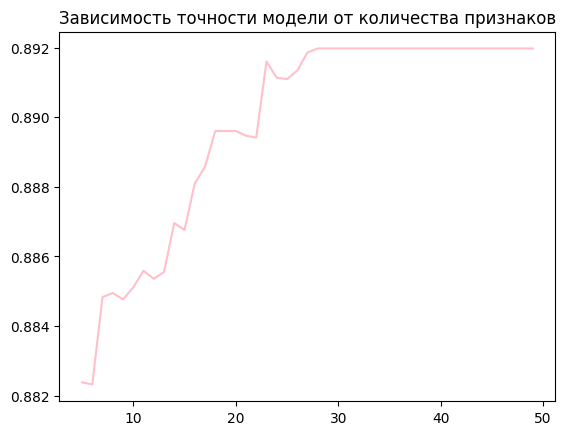

In [58]:
plt.plot(list(scores.keys()), list(scores.values()), color='pink')
plt.title('Зависимость точности модели от количества признаков')

#### 2. Используйте другие методы отбора признаков:
- Исключение низкодисперсных признаков;
- Исключение по парным стаистическим критериям (хи-квадрат, тест Фишера, коэффициент корреляции, информационный критерий);
- Рекурсивное исключение признаков;
- Последовательное включение признаков;
Исключение по L1-норме (гребневой регрессии).

##### Исключение низкодисперсных признаков

In [46]:
from sklearn.feature_selection import VarianceThreshold

df_low_variance = fetch_openml("CPMP-2015-regression", version=1)
df_low_variance.data.drop(["instance_id"], inplace=True, axis=1)
df_low_variance.data = pd.get_dummies(df_low_variance.data)

X_train_lv, X_test_lv, y_train_lv, y_test_lv = train_test_split(df_low_variance.data, df_low_variance.target, test_size=0.25, random_state=42)

selector = VarianceThreshold(threshold=0.0)

X_train_lv_selected = selector.fit_transform(X_train_lv)
X_test_lv_selected = selector.transform(X_test_lv)

print(f"Original features: {X_train_lv.shape[1]}")
print(f"Number of features after VarianceThreshold: {X_train_lv_selected.shape[1]}")

model_lv = LinearRegression()
model_lv.fit(X_train_lv_selected, y_train_lv)

score_lv = model_lv.score(X_test_lv_selected, y_test_lv)
print(f"\nBaseline: {bl_score}")
print(f"Model with low variance exclusion: {score_lv}")

Original features: 30
Number of features after VarianceThreshold: 29

Baseline: 0.8598726114649682
Model with low variance exclusion: 0.891977926998725


/tmp/ipykernel_1015/1869054071.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_low_variance.data.drop(["instance_id"], inplace=True, axis=1)


##### Исключение по парным статистическим критериям (коэффициент корреляции)

In [47]:
df_corr = fetch_openml("CPMP-2015-regression", version=1)
df_corr.data.drop(["instance_id"], inplace=True, axis=1)
df_corr.data = pd.get_dummies(df_corr.data)

X_corr, y_corr = df_corr.data, df_corr.target

full_df = pd.concat([X_corr, y_corr.rename('target')], axis=1)
correlations = full_df.corr()['target'].abs().sort_values(ascending=False)

print("Top features by correlation:")
print(correlations.head(11))

correlation_threshold = 0.1
selected_features_corr = correlations[correlations > correlation_threshold].index.tolist()

if 'target' in selected_features_corr:
    selected_features_corr.remove('target')

print(f"\nNumber of features based on correlation threshold ({correlation_threshold}): {len(selected_features_corr)}")
print(f"Selected features: {selected_features_corr}")


X_selected_corr = X_corr[selected_features_corr]

X_train_corr, X_test_corr, y_train_corr, y_test_corr = train_test_split(X_selected_corr, y_corr, test_size=0.25, random_state=42)

model_corr = LinearRegression()
model_corr.fit(X_train_corr, y_train_corr)

score_corr = model_corr.score(X_test_corr, y_test_corr)
print(f"\nBaseline score (from previous run): {bl_score}")
print(f"Model score with correlation-based feature selection: {score_corr}")

Top features by correlation:
target               1.000000
runstatus_ok         0.950470
runstatus_memout     0.711281
runstatus_timeout    0.513289
bflb                 0.343560
overstowage.pct      0.258446
stacks               0.229951
top.good.mean        0.199531
top.good.max         0.198312
group.same.min       0.188913
stack.tier.ratio     0.168930
Name: target, dtype: float64

Number of features based on correlation threshold (0.1): 17
Selected features: ['runstatus_ok', 'runstatus_memout', 'runstatus_timeout', 'bflb', 'overstowage.pct', 'stacks', 'top.good.mean', 'top.good.max', 'group.same.min', 'stack.tier.ratio', 'container.density', 'group.same.max', 'top.good.stdev', 'group.same.mean', 'group.same.stdev', 'pct.bottom.pct.on.top', 'top.good.min']

Baseline score (from previous run): 0.8598726114649682
Model score with correlation-based feature selection: 0.8810358453747316


/tmp/ipykernel_1015/4244506614.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corr.data.drop(["instance_id"], inplace=True, axis=1)


##### Рекурсивное исключение признаков

In [48]:
from sklearn.feature_selection import RFE

df_rfe = fetch_openml("CPMP-2015-regression", version=1)
df_rfe.data.drop(["instance_id"], inplace=True, axis=1)
df_rfe.data = pd.get_dummies(df_rfe.data)

X_rfe, y_rfe = df_rfe.data, df_rfe.target

X_train_rfe, X_test_rfe, y_train_rfe, y_test_rfe = train_test_split(X_rfe, y_rfe, test_size=0.25, random_state=42)

baseline_rfe = LinearRegression()
baseline_rfe.fit(X_train_rfe, y_train_rfe)
bl_score_rfe = baseline_rfe.score(X_test_rfe, y_test_rfe)

print(f"Baseline score: {bl_score_rfe}")

estimator = LinearRegression()
rfe_selector = RFE(estimator=estimator, n_features_to_select=10, step=1)
rfe_selector.fit(X_train_rfe, y_train_rfe)

X_train_rfe_selected = rfe_selector.transform(X_train_rfe)
X_test_rfe_selected = rfe_selector.transform(X_test_rfe)

print(f'Original number of features: {X_train_rfe.shape[1]}')
print(f'Number of features RFE: {X_train_rfe_selected.shape[1]}')

model_rfe = LinearRegression()
model_rfe.fit(X_train_rfe_selected, y_train_rfe)

score_rfe = model_rfe.score(X_test_rfe_selected, y_test_rfe)
print(f"score with RFE: {score_rfe}")

/tmp/ipykernel_1015/2244741993.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rfe.data.drop(["instance_id"], inplace=True, axis=1)


Baseline score: 0.891977926998725
Original number of features: 30
Number of features RFE: 10
score with RFE: 0.8860847053316712


##### Последовательное включение признаков

In [49]:
from sklearn.feature_selection import SequentialFeatureSelector

df_sfs = fetch_openml("CPMP-2015-regression", version=1)
df_sfs.data.drop(["instance_id"], inplace=True, axis=1)
df_sfs.data = pd.get_dummies(df_sfs.data)

X_sfs, y_sfs = df_sfs.data, df_sfs.target

X_train_sfs, X_test_sfs, y_train_sfs, y_test_sfs = train_test_split(X_sfs, y_sfs, test_size=0.25, random_state=42)

estimator_sfs = LinearRegression()

sfs = SequentialFeatureSelector(estimator_sfs, n_features_to_select=10, direction='forward', cv=2, n_jobs=-1) # Use n_jobs=-1 for parallel processing
sfs.fit(X_train_sfs, y_train_sfs)

X_train_sfs_selected = X_train_sfs.loc[:, sfs.get_support()]
X_test_sfs_selected = X_test_sfs.loc[:, sfs.get_support()]

print(f"Original number of features: {X_train_sfs.shape[1]}")
print(f"Number of features after Sequential Feature Selection: {X_train_sfs_selected.shape[1]}")
print(f"Selected features: {X_train_sfs_selected.columns.tolist()}")

model_sfs = LinearRegression()
model_sfs.fit(X_train_sfs_selected, y_train_sfs)

score_sfs = model_sfs.score(X_test_sfs_selected, y_test_sfs)
print(f"Baseline score: {bl_score_rfe}")
print(f"Model score sfs: {score_sfs}")

/tmp/ipykernel_1015/4006297772.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sfs.data.drop(["instance_id"], inplace=True, axis=1)


Original number of features: 30
Number of features after Sequential Feature Selection: 10
Selected features: ['stacks', 'tiers', 'stack.tier.ratio', 'container.density', 'overstowage.pct', 'bflb', 'tier.weighted.groups', 'algorithm_idastar.symmulgt.transmul', 'algorithm_idastar.symmullt.transmul', 'runstatus_ok']
Baseline score: 0.891977926998725
Model score sfs: 0.8913434289961294


##### Исключение по L1-норме (гребневой регрессии)

In [50]:
from sklearn.linear_model import Lasso

df_lasso = fetch_openml("CPMP-2015-regression", version=1)
df_lasso.data.drop(["instance_id"], inplace=True, axis=1)
df_lasso.data = pd.get_dummies(df_lasso.data)

X_lasso, y_lasso = df_lasso.data, df_lasso.target

X_train_lasso, X_test_lasso, y_train_lasso, y_test_lasso = train_test_split(X_lasso, y_lasso, test_size=0.25, random_state=42)

lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train_lasso, y_train_lasso)

selected_features_lasso = X_train_lasso.columns[lasso.coef_ != 0].tolist()


if not selected_features_lasso:
    print("Lasso selected no features. Adjusting alpha or using all features.")

    lasso = Lasso(alpha=0.01, random_state=42)
    lasso.fit(X_train_lasso, y_train_lasso)
    selected_features_lasso = X_train_lasso.columns[lasso.coef_ != 0].tolist()
    if not selected_features_lasso:
        selected_features_lasso = X_train_lasso.columns.tolist()

X_train_lasso_selected = X_train_lasso[selected_features_lasso]
X_test_lasso_selected = X_test_lasso[selected_features_lasso]

print(f"Original number of features: {X_train_lasso.shape[1]}")
print(f"Number of features after L1-norm (Lasso) selection: {X_train_lasso_selected.shape[1]}")
print(f"Selected features: {selected_features_lasso}")

model_lasso = LinearRegression()
model_lasso.fit(X_train_lasso_selected, y_train_lasso)

score_lasso = model_lasso.score(X_test_lasso_selected, y_test_lasso)
print(f"Baseline score (from RFE, full features): {bl_score_rfe}")
print(f"Model score with L1-norm (Lasso) feature selection: {score_lasso}")

/tmp/ipykernel_1015/4147115513.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lasso.data.drop(["instance_id"], inplace=True, axis=1)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.707e+06, tolerance: 3.824e+05
  model = cd_fast.enet_coordinate_descent(


Original number of features: 30
Number of features after L1-norm (Lasso) selection: 29
Selected features: ['stacks', 'tiers', 'stack.tier.ratio', 'container.density', 'empty.stack.pct', 'overstowing.stack.pct', 'overstowing.2cont.stack.pct', 'group.same.min', 'group.same.max', 'group.same.mean', 'group.same.stdev', 'top.good.min', 'top.good.max', 'top.good.mean', 'top.good.stdev', 'overstowage.pct', 'bflb', 'left.density', 'tier.weighted.groups', 'avg.l1.top.left.lg.group', 'cont.empty.grt.estack', 'pct.bottom.pct.on.top', 'algorithm_astar.symmulgt.transmul', 'algorithm_astar.symmullt.transmul', 'algorithm_idastar.symmulgt.transmul', 'algorithm_idastar.symmullt.transmul', 'runstatus_memout', 'runstatus_ok', 'runstatus_timeout']
Baseline score (from RFE, full features): 0.891977926998725
Model score with L1-norm (Lasso) feature selection: 0.891977926998725


#### 3. Изучите возможности библиотеки imbalanced-learn. Примените на данном примере возможности данной библиотеки для оверсемплинга и андерсемплинга выборки.

In [51]:
from imblearn.over_sampling import SMOTE

df_balance = fetch_openml("balance-scale", version=1)
X_bal, y_bal = df_balance.data, df_balance.target

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_bal, y_bal, test_size=0.25, random_state=42, stratify=y_bal)

print('Original target:')
print(y_train_bal.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_bal, y_train_bal)

print("target after SMOTE:")
print(y_train_smote.value_counts())

model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

score_smote = model_smote.score(X_test_bal, y_test_bal)
print(f'\n score with SMOTE oversampling: {score_smote}')
print('Classification Report for SMOTE:')
print(classification_report(y_test_bal, model_smote.predict(X_test_bal)))

Original target:
class
R    216
L    215
B     37
Name: count, dtype: int64
target after SMOTE:
class
B    216
L    216
R    216
Name: count, dtype: int64

 score with SMOTE oversampling: 0.8853503184713376
Classification Report for SMOTE:
              precision    recall  f1-score   support

           B       0.46      0.92      0.61        12
           L       0.97      0.90      0.94        73
           R       0.95      0.86      0.91        72

    accuracy                           0.89       157
   macro avg       0.79      0.89      0.82       157
weighted avg       0.92      0.89      0.90       157



#### 4. Исследуйте влияние дискретизации целевой переменной на качество модели. Используйте уже продемострированный подход - построение базовой модели (baseline) и сравнение модели после обработки данных с базовой. Проверьте разное количество категорий, а также разные стратегии группировки. Сделайте выводы. Обратите внимание, что после биннинга целевой переменной она стала категориальной. А значит, задача превратилась в задачу классификации.

In [57]:
df = fetch_openml("CPMP-2015-regression", version=1, as_frame=True)
X = pd.get_dummies(df.data.drop(["instance_id"], axis=1))
y = df.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

base_model = LinearRegression()
base_model.fit(X_train_scaled, y_train)
base_mae = mean_absolute_error(y_test, base_model.predict(X_test_scaled))
print(f'Baseline MAE: {base_mae:.4f}')

configs = [
    (5, 'uniform'), (5, 'quantile'), (5, 'kmeans'),
    (10, 'uniform'), (10, 'quantile'), (10, 'kmeans')
]

for n_bins, strategy in configs:
    kbd = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy=strategy, subsample=None)

    y_tr_binned = kbd.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    y_te_binned = kbd.transform(y_test.values.reshape(-1, 1)).ravel()

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_scaled, y_tr_binned)

    acc = clf.score(X_test_scaled, y_te_binned)


    bin_centers = (kbd.bin_edges_[0][:-1] + kbd.bin_edges_[0][1:]) / 2
    y_pred_numeric = bin_centers[clf.predict(X_test_scaled).astype(int)]
    binned_mae = mean_absolute_error(y_test, y_pred_numeric)

    print(f'Bins: {n_bins}, Strat: {strategy:8} | Acc: {acc:.3f} | MAE: {binned_mae:.4f}')

Baseline MAE: 270.8407
Bins: 5, Strat: uniform  | Acc: 0.918 | MAE: 429.8976
Bins: 5, Strat: quantile | Acc: 0.666 | MAE: 798.2725


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


Bins: 5, Strat: kmeans   | Acc: 0.886 | MAE: 335.6543
Bins: 10, Strat: uniform  | Acc: 0.884 | MAE: 300.1114


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


Bins: 10, Strat: quantile | Acc: 0.528 | MAE: 557.3408
Bins: 10, Strat: kmeans   | Acc: 0.818 | MAE: 248.1173
